# Subject Level GNN

## Setup

In [1]:
# Get content from Drive
from google.colab import drive
drive.mount('/content/drive')

# Get GitHub token from Colab secrets
from google.colab import userdata
token = userdata.get('github_token')

# Clone the repo if it doesn't exist. Pull the latest otherwise
import os
if not os.path.exists('/content/agnn'):
    !git clone https://{token}@github.com/charlottedavidson524/alzheimers-gnn.git /content/agnn
%cd /content/agnn
!git pull

# nstall project. Need to do this after a fresh clone
!pip install -e . --quiet
!pip install torch-geometric --quiet

# Copy subject-level graphs to local storage for faster access
if not os.path.exists("/content/graphs_subject"):
    !cp -r /content/drive/MyDrive/alzheimers-gnn-data/graphs_subject /content/graphs_subject
if not os.path.exists("/content/participants.tsv"):
    !cp /content/drive/MyDrive/alzheimers-gnn-data/participants.tsv /content/participants.tsv

# GPU check
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/agnn
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for agnn (pyproject.toml) ... done
GPU: Tesla T4


Now that everything is setup correctly, move onto the imports

In [2]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from agnn.paths import get_results_root
from agnn.gnn.model import MultiBandGCN
from agnn.gnn.data import load_subject_graphs, pair_by_subject, make_cv_splits, make_dataloader, verify_no_subject_leakage
from agnn.gnn.train import train_fold, set_seed

# Check what device is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Make sure thius points at the subject level graphs directory, not per epoch
GRAPHS_ROOT = Path("/content/graphs_subject")
print(f"Graphs root: {GRAPHS_ROOT}")

Device: cuda
Graphs root: /content/graphs_subject


Using cuda and is pointing at subject level graphs directory. Can move on to the new config.

In [3]:
config = {
    # Model hyperparameters
    "hidden_channels": 64,
    "embedding_dim": 32,
    "mlp_hidden": 32,
    "dropout": 0.5,

    # Training hyperparameters
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 8,
    "epochs": 300,
    "patience": 20,
    "class_weights": [1.5, 1.0],

    # Cross-validation
    "n_folds": 5,
    "seed": 42,
}

# Print config to check eveerything looks right
print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config:
  hidden_channels: 64
  embedding_dim: 32
  mlp_hidden: 32
  dropout: 0.5
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 8
  epochs: 300
  patience: 20
  class_weights: [1.5, 1.0]
  n_folds: 5
  seed: 42


What has changed with regards to the hyperparamaters:

- The model hyperparameters have been kept the same as per epoch.

- However the training hyperparameters have been adjusted because the dataset is smaller and there are only 77 samples. Batch size has been cut bnecause of fewer training samples per fold and epochs are higher because there is less data per epoch.

Now load and pair subjects, using pair_by_subject() this time instead of pair_by_epoch().

In [8]:
# Find all the subject folders in the subject level graph directory
subjects = sorted([d.name for d in GRAPHS_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(subjects)} subjects at {GRAPHS_ROOT}")

# Load and pair all graphs by subject. Each subject should have two graphs, delta and alpha-2/
graphs = load_subject_graphs(subjects, GRAPHS_ROOT)
pairs = pair_by_subject(graphs)

# Check on the cohort summary
n_positive = sum(p[2] for p in pairs)
print(f"Total pairs: {len(pairs)}")
print(f"Positive class (carriers): {n_positive} ({n_positive/len(pairs):.1%})")
print(f"Negative class (non-carriers): {len(pairs)-n_positive} ({(len(pairs)-n_positive)/len(pairs):.1%})")

Found 77 subjects at /content/graphs_subject
Total pairs: 77
Positive class (carriers): 46 (59.7%)
Negative class (non-carriers): 31 (40.3%)


found 77 subjects and 77 pairs as expected. Class balance is correct and in line with what is known. Move on to creating CV splits and the results directory.

In [9]:
# Create CV splits at the subject level where each pair is a subject
set_seed(config["seed"])
splits = make_cv_splits(pairs, n_folds=config["n_folds"], seed=config["seed"])
print(f"Created {len(splits)} folds")

# This code creates timestamped results directory in Drive (this is useful to see whats happening when)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = get_results_root()/f"run_subject_{timestamp}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will save to: {run_dir}")

# Save config used for this run
with open(run_dir/"config.json", "w") as f:
    json.dump(config, f, indent=2)

Created 5 folds
Results will save to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260804_154300


Now run the 5 fold CV

In [10]:
# Empty list to store fold results
fold_results = []

# Main CV loop. Each iteration trains and evaluates one fold end-to-end.
for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}/{config['n_folds']}")
    print(f"{'='*60}")

    # Use the defensive leakage check function created earlier to check for subject leakage
    verify_no_subject_leakage(pairs, train_idx, val_idx)

    # Report fold composition
    train_labels = [pairs[i][2] for i in train_idx]
    val_labels = [pairs[i][2] for i in val_idx]
    train_subjects = {pairs[i][0].subject_id for i in train_idx}
    val_subjects = {pairs[i][0].subject_id for i in val_idx}

    # For both train and validation datasets, record the number of pairs, subjects, and percentage of carriers
    print(f"Train: {len(train_idx)} pairs, {len(train_subjects)} subjects, {sum(train_labels)}/{len(train_labels)} positive ({sum(train_labels)/len(train_labels):.1%})")
    print(f"Val: {len(val_idx)} pairs, {len(val_subjects)} subjects, {sum(val_labels)}/{len(val_labels)} positive ({sum(val_labels)/len(val_labels):.1%})")

    # Fresh model per fold to ensure independent training
    set_seed(config["seed"]+fold_idx) # different seed per fold, but reproducible

    # Model. Values come from the config
    model = MultiBandGCN(hidden_channels=config["hidden_channels"], embedding_dim=config["embedding_dim"], mlp_hidden=config["mlp_hidden"],
                         dropout=config["dropout"]).to(device)

    # Create train and validation loaders for the fold
    train_loader = make_dataloader(pairs, train_idx, batch_size=config["batch_size"], shuffle=True)
    val_loader = make_dataloader(pairs, val_idx, batch_size=config["batch_size"], shuffle=False)

    # Create fold directory for outputs
    fold_dir = run_dir/f"fold_{fold_idx}"
    fold_dir.mkdir(exist_ok=True)

    # Train this fold
    result = train_fold(model=model, train_loader=train_loader, val_loader=val_loader, config=config, device=device,
        checkpoint_path=fold_dir/"best_model.pt", verbose=True)

    # Save the training history. Use it to plot curves later on
    with open(fold_dir/"history.json", "w") as f:
        json.dump(result["history"], f, indent=2)

    # Save predictions at best epoch. used later for downstream metrics
    np.savez(fold_dir/"predictions.npz", y_true=result["best_metrics"]["y_true"], y_prob=result["best_metrics"]["y_prob"])

    # Save a fold level metrics summary
    y_true = result["best_metrics"]["y_true"]
    y_prob = result["best_metrics"]["y_prob"]
    y_pred = (y_prob > 0.5).astype(int)

    # Collect the metrics and metadata into a dictionary for this particular fold
    fold_summary = {
        "fold": fold_idx,
        "best_auc": result["best_auc"],
        "best_epoch": result["best_epoch"],
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
    }

    # Save the fold summary to disk. Allows for later analysis
    with open(fold_dir/"metrics.json", "w") as f:
        json.dump(fold_summary, f, indent=2)


    # Append to the running list created at the beginning. Used later for cross-fold aggregation.
    fold_results.append(fold_summary)

    print(f"\nFold {fold_idx + 1} complete: AUC = {result['best_auc']:.4f} at epoch {result['best_epoch']}")


Fold 1/5
Train: 61 pairs, 61 subjects, 37/61 positive (60.7%)
Val: 16 pairs, 16 subjects, 9/16 positive (56.2%)
Epoch   1/300: train_loss=0.7020, val_loss=0.7034, val_auc=0.5714
Epoch   2/300: train_loss=0.6963, val_loss=0.7009, val_auc=0.5714
Epoch   3/300: train_loss=0.6997, val_loss=0.6993, val_auc=0.5873
Epoch   4/300: train_loss=0.6856, val_loss=0.6969, val_auc=0.5714
Epoch   5/300: train_loss=0.6992, val_loss=0.6946, val_auc=0.5714
Epoch   6/300: train_loss=0.6893, val_loss=0.6934, val_auc=0.5714
Epoch   7/300: train_loss=0.6986, val_loss=0.6931, val_auc=0.5714
Epoch   8/300: train_loss=0.6927, val_loss=0.6927, val_auc=0.5714
Epoch   9/300: train_loss=0.6967, val_loss=0.6921, val_auc=0.5873
Epoch  10/300: train_loss=0.6991, val_loss=0.6912, val_auc=0.5873
Epoch  11/300: train_loss=0.6913, val_loss=0.6914, val_auc=0.5873
Epoch  12/300: train_loss=0.7066, val_loss=0.6913, val_auc=0.5873
Epoch  13/300: train_loss=0.6923, val_loss=0.6912, val_auc=0.5873
Epoch  14/300: train_loss=0.6

Fold level results already looking improved, however check other metrics. Below is the aggregated cross fold metrics

In [11]:
# Build cross-fold summary df
summary_df = pd.DataFrame(fold_results)
summary_df.to_csv(run_dir/"cross_fold_metrics.csv", index=False)
print("Cross-fold metrics:")
print(summary_df.to_string(index=False))

# Create overall statistics
mean_auc = summary_df["best_auc"].mean()
std_auc = summary_df["best_auc"].std()
mean_f1 = summary_df["f1"].mean()

# Show a printed summary
print(f"\n{'='*60}")
print(f"Cross-fold summary (subject level, n_folds={config['n_folds']})")
print(f"{'='*60}")
print(f"AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
print(f"F1: {mean_f1:.4f} +/- {summary_df['f1'].std():.4f}")
print(f"Precision: {summary_df['precision'].mean():.4f} +/- {summary_df['precision'].std():.4f}")
print(f"Recall: {summary_df['recall'].mean():.4f} +/- {summary_df['recall'].std():.4f}")

# Save top-level summary
top_summary = {
    "config": config,
    "aggregation": "subject-level",
    "n_subjects": len(subjects),
    "n_pairs": len(pairs),
    "class_balance": {
        "positive": n_positive,
        "negative": len(pairs) - n_positive,
        "ratio_pos": n_positive / len(pairs),
    },
    "cross_fold_auc": {
        "mean": float(mean_auc),
        "std": float(std_auc),
        "per_fold": summary_df["best_auc"].tolist(),
    },
    "cross_fold_f1": {
        "mean": float(mean_f1),
        "std": float(summary_df["f1"].std()),
    },
}

# Write the top level summary to the disk in Drive so it can survive session end
with open(run_dir/"summary.json", "w") as f:
    json.dump(top_summary, f, indent=2)

print(f"\nAll results saved to: {run_dir}")

Cross-fold metrics:
 fold  best_auc  best_epoch  precision  recall   f1  n_train  n_val  n_train_subjects  n_val_subjects
    0  0.587302           3        0.0     0.0 0.00       61     16                61              16
    1  0.833333          11        0.0     0.0 0.00       61     16                61              16
    2  0.537037           1        0.0     0.0 0.00       62     15                62              15
    3  0.648148           4        0.6     1.0 0.75       62     15                62              15
    4  0.574074           1        0.0     0.0 0.00       62     15                62              15

Cross-fold summary (subject level, n_folds=5)
AUC: 0.6360 +/- 0.1174
F1: 0.1500 +/- 0.3354
Precision: 0.1200 +/- 0.2683
Recall: 0.2000 +/- 0.4472

All results saved to: /content/drive/MyDrive/alzheimers-gnn-data/results/run_subject_20260804_154300


Show the training curves

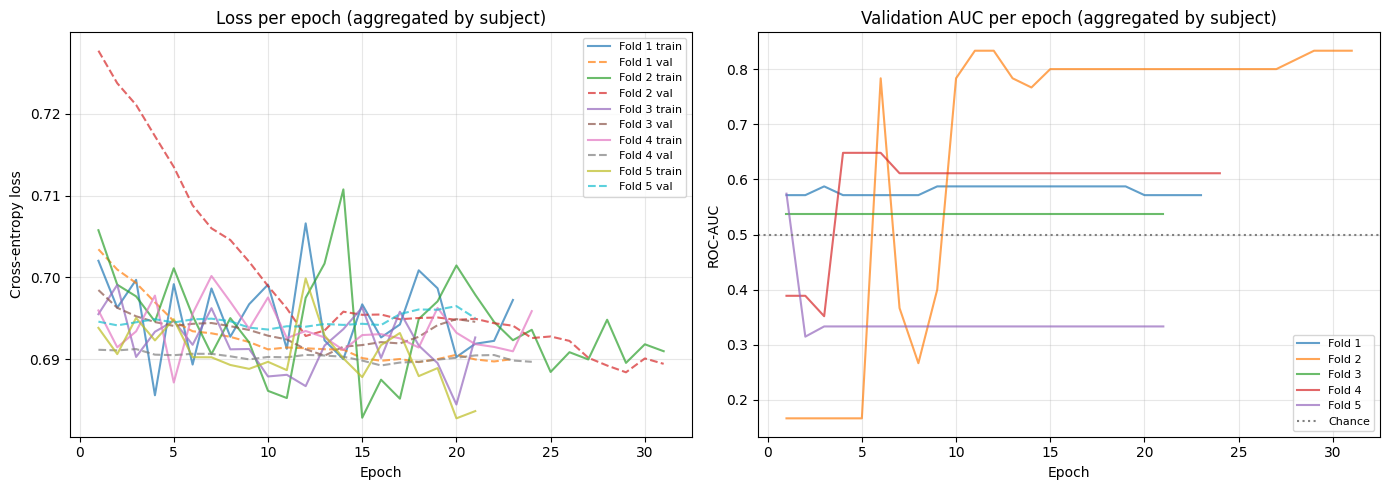

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterate over the folds. Log each fold's saved history and plot its curves.
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    with open(fold_dir/"history.json") as f:
        history = json.load(f)

    # Left axis will be train/validation loss curves. Right will be validation AUC
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label=f"Fold {fold_idx+1} train", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label=f"Fold {fold_idx+1} val", linestyle="--", alpha=0.7)
    axes[1].plot(epochs, history["val_auc"], label=f"Fold {fold_idx+1}", alpha=0.7)

# Title, labels, legend and grid for left hand graph
axes[0].set_title("Loss per epoch (aggregated by subject)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(alpha=0.3)

# Title, labels, legend and grid for right hand graph
axes[1].set_title("Validation AUC per epoch (aggregated by subject)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].axhline(y=0.5, color="gray", linestyle=":", label="Chance")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# Display and save graphs
plt.tight_layout()
plt.savefig(run_dir/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves plot

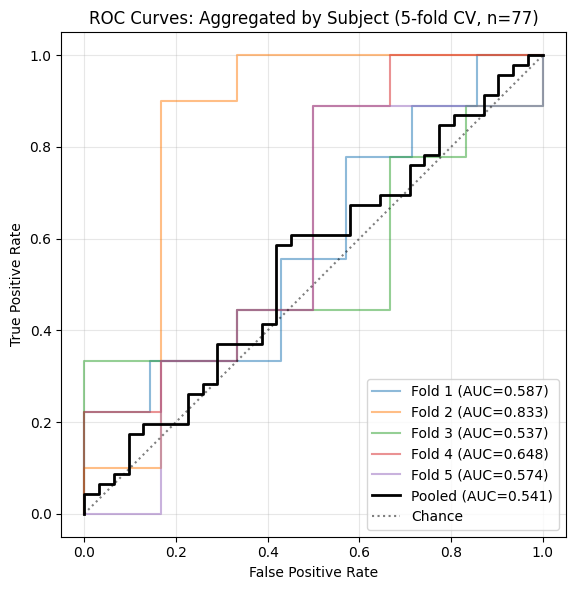

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the ROC curve for each fold individually, this shows the variation between folds
for fold_idx in range(config["n_folds"]):
    fold_dir = run_dir/f"fold_{fold_idx}"
    preds = np.load(fold_dir/"predictions.npz")
    fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
    auc = roc_auc_score(preds["y_true"], preds["y_prob"])
    ax.plot(fpr, tpr, alpha=0.5, label=f"Fold {fold_idx+1} (AUC={auc:.3f})")

# Prepare lists to collect predictions across folds for the pooled ROC
all_y_true = []
all_y_prob = []

# Load each fold's predictions and append to the running lsist
for fold_idx in range(config["n_folds"]):
    preds = np.load(run_dir/f"fold_{fold_idx}"/"predictions.npz")
    all_y_true.append(preds["y_true"])
    all_y_prob.append(preds["y_prob"])

# Flatten into single arrays covering the whole cohort
all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

# Compute the pooled ROC and AUC across all folds combined
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
pooled_auc = roc_auc_score(all_y_true, all_y_prob)

# Draw the pooled ROC on top of the per-fold curves. This should give a cohort-level view
ax.plot(fpr, tpr, color="black", linewidth=2, label=f"Pooled (AUC={pooled_auc:.3f})")

# The chance line
ax.plot([0, 1], [0, 1], "k:", alpha=0.5, label="Chance")

# Labels, title, legend and grid for the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves: Aggregated by Subject (5-fold CV, n={len(subjects)})")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_aspect("equal")

# Display and save plot
plt.tight_layout()
plt.savefig(run_dir/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## SUBJECT LEVEL GNN RESULTS

The per-epoch GNN training pipeline resulted in a mean AUC of 0.556 +/- 0.091 across 5-fold CV. These results had high variance (best fold was 0.68 and worst was 0.47). The performance was only modest and the behaviour per fold was unstable. All led to the question of if the underlting signal was getting obscured by per-epoch noise.

Pre-symptomatoic APOE e4 effectrs on resting state EEG connectivity are subtle and could be more likely detectable at the subject level rather than at the per epoch level. So I could test this, wPLI matrices and node features were averaged across all epochs per subject. this created one graph per band per subject (2 total) rather than one graph per epoch per band (around 360 total).

The results are as follows:

| Metric | Per-epoch | Subject-level | Difference|
|---|---|---|---|
| Mean AUC | 0.556 +/- 0.091 | 0.636 +/- 0.117 | +0.080 |
| Best fold | 0.684 | 0.833 | +0.149 |
| Worst fold | 0.469 | 0.537 | +0.068 |
| F1 (mean) | 0.259 | 0.150 | −0.109 |

The breakdown per fold is as follows:

| Fold | AUC | Best epoch | Val subjects | Val positive rate |
|------|-----|-----------|--------------|-------------------|
| 1 | 0.587 | 3 | 16 | 56% |
| 2 | 0.833 | 11 | 16 | 63% |
| 3 | 0.537 | 1 | 15 | 60% |
| 4 | 0.648 | 4 | 15 | 60% |
| 5 | 0.574 | 1 | 15 | 60% |

The subject level approach improved mean AUC by 0.08 and pushed the best fold to 0.833, which matched or exceeded the tabular baselines.

The big improvement in mean AUC and the even bigger improvement in the best fold show meaningful evidence that pre-symptomatic APOE e4 effects on EEG connectivity operate more at the subject level than the epoch level. Averaging wPLI across epochs removed noise that was diluting the discriminative signal. This exposed subject-level connectivity patterns that the GNN could learn from.

However, there are concerns with variance and overfitting. Cross-fold variance is still high (std = 0.117), and there are more than one patterns in the training curves that indicate potential overfitting:

- The best epochs happen very early.In 4/5 folds, the best validation AUC happened within the first 4 epochs. Suggests the initial random weights produced reasonable rankings, and the training that followed didnt cause any substantial improvement. This is a sign that the small dataset (77 total samples) does not provide enough signal for the model to learn generalisable patterns beyond what random initialisation produces.

- Training loss barely decreases. Across all of the folds, training loss stayed close to 0.69 (which is roughly the class-weighted cross-entropy baseline). The model is not actually learning to discriminate on the training set, let alone generalising to validation.

- Threshold-based classification is poor. 4/5 folds have precision, recall, and F1 of zero. This is because the model's outputs cluster near 0.5, and thresholding at 0.5 produces mostly majority-class predictions with almost no true positives. AUC is still meaningful because it captures ranking ability rather than threshold-based decisions. However, downstream applications requiring binary predictions would need calibrated thresholds or different training goals.

This all suggests that the model is capturing genuine but modest signal but doesn't achieve confident clasification of all individual carriers. However, the results also indicate that the signal itself is inherently weak at this cohort size. High variance, early convergence, and poor threshold-based metrics suggest that even the best representation can't fully compensate for the fact that this is a hard task at n= 77. Improvements beyond this level are most likely going to come from additional data or multi-modal fusion rather than from further refinement of the current GNN architecture.

Some limitations need to be acknowledged when interpreting these results:

- Cohort is small (n=77). With 15–16 subjects per validation fold, individual subjects dominate the AUC, which produces the high cross-fold variance observed.

- Class imbalance (60% carriers). Cross-fold splits are stratified, but the mild imbalance still affects the class-weighted loss and threshold-based metrics.

- Four of five folds achieved their best AUC in the first 4 epochs, suggesting the model relies more on random initialisation than on patterns that are being learned. This limits the interpretability of the "best AUC" as a measure of what the model can learn.

- The fact that averaging discards information. Subject-level aggregation removes epoch-level variability that could contain meaningful signal even if that signal is not APOE related. Whether this variability could be productive rather than noisy hasn't been tested,

There is potentially some room for imporvement using fusion. The best tabular baseline on this cohort achieves 0.830 AUC. The subject-level GNN achieves 0.636 mean AUC with a peak of 0.833. Late fusion could poetntially result in further improvement. However, this is if the GNN and tabular models make errors on different subjects (this way their combined predictions can exceed both individual models). If they error on similar subjects, fusion may not offer much benefits. Worth a look into.

The GNN's strongest fold (0.833) shows that EEG connectivity could contain complementary predictive signal to the tabular features. Fusion would test whether this holds on average across the cohort.